# Visualization of Kao et al.'s metrics

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal
from scikit_posthocs import posthoc_dunn

In [2]:
results_dir = Path('../../results/kaoetal')
dfs = []
for result in results_dir.iterdir():
    corpus_name = result.stem
    df = pl.read_ndjson(result).with_columns(pl.lit(corpus_name).alias('corpus'))
    dfs.append(df)

datasets_enum = pl.Enum(['humicroedit', 'puntuguese'])

# Dataframe has no 'label' column because they are all humorous texts
# They need to be humorous because we need pun and alternative words
# for the metric
df = (pl.concat(dfs, how='diagonal')
        .sort(pl.col('corpus').cast(datasets_enum)))
df

index,text,location,interpretation,char_count,ambiguity,distinctiveness,corpus,funniness
str,str,str,str,i64,f64,f64,str,f64
"""humicroedit.14530.H""","""France is ‘ hunting down its c…","""twins""","""Isis""",null,0.000008,0.0,"""humicroedit""",0.2
"""humicroedit.13034.H""","""Pentagon claims 2,000 % increa…","""bowling""","""Syria""",null,1.0,0.0,"""humicroedit""",1.6
"""humicroedit.8731.H""","""Iceland PM Calls Snap Vote as …","""party""","""Coalition""",null,0.344281,0.0,"""humicroedit""",1.0
"""humicroedit.76.H""","""In an apparent first , Iran an…","""slap""","""engage""",null,0.000003,0.0,"""humicroedit""",0.4
"""humicroedit.8832.H""","""All 22 sounds Trump made in hi…","""sounds""","""promises""",null,0.780144,0.0,"""humicroedit""",1.2
…,…,…,…,…,…,…,…,…
"""puntuguese.4.177.H""","""Porque é que o Dobby, o elfo d…","""elfo dilhão""","""el fodilhão""",162,null,null,"""puntuguese""",null
"""puntuguese.4.362.H""","""Uma família estava perdida no …","""a avó tá imunda há 80 dias""","""a volta ao mundo em 80 dias""",171,null,null,"""puntuguese""",null
"""puntuguese.4.476.H""","""Uma freira tinha de pôr suposi…","""Cal-cu-tá""","""qual cu tá""",189,null,null,"""puntuguese""",null


## Check null values

In [3]:
(df.filter(pl.col('ambiguity').is_null() | pl.col('distinctiveness').is_null())
   .group_by('corpus').len())

corpus,len
str,u64
"""puntuguese""",26


In [4]:
df = df.drop_nulls(['ambiguity', 'distinctiveness'])
(df.group_by('corpus').len())

corpus,len
str,u64
"""puntuguese""",2824
"""humicroedit""",14296


## Plots

### Ambiguity

In [5]:
quantiles = (df.group_by('corpus')
               .agg(pl.col('ambiguity').quantile(0.25).alias('Q1'),
                    pl.col('ambiguity').quantile(0.5).alias('Q2'),
                    pl.col('ambiguity').quantile(0.75).alias('Q3'))
               .with_columns((pl.col('Q3') - pl.col('Q1')).alias('IQR'))
               .with_columns((pl.col('Q1') - 1.5 * pl.col('IQR')).alias('F1'),
                             (pl.col('Q3') + 1.5 * pl.col('IQR')).alias('F2')))
quantiles

corpus,Q1,Q2,Q3,IQR,F1,F2
str,f64,f64,f64,f64,f64,f64
"""puntuguese""",1.0,1.0,1.0,0.0,1.0,1.0
"""humicroedit""",0.000003,0.261491,0.947863,0.94786,-1.421787,2.369653


In [7]:
df_with_quantiles = df.join(quantiles, on='corpus')
is_low_outlier = (pl.col('ambiguity') < pl.col('F1'))
is_high_outlier = (pl.col('ambiguity') > pl.col('F2'))
df_no_outliers_amb = df_with_quantiles.filter(~(is_low_outlier | is_high_outlier)).select(df.columns)
df_no_outliers_amb.group_by('corpus').len()

corpus,len
str,u64
"""puntuguese""",2290
"""humicroedit""",14296


#### Ambiguity values without outliers

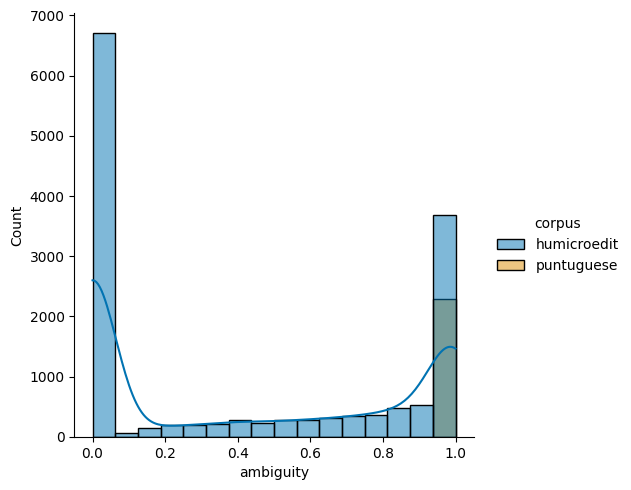

In [8]:
sns.displot(data=df_no_outliers_amb, x='ambiguity',
            hue='corpus', palette='colorblind', kde=True)
plt.savefig('../../results/img/kaoetal_ambiguity.pdf')

#### Humicroedit Ambiguity vs. Funniness

In [9]:
df_humicroedit_amb = df_no_outliers_amb.filter(pl.col('corpus') == 'humicroedit')

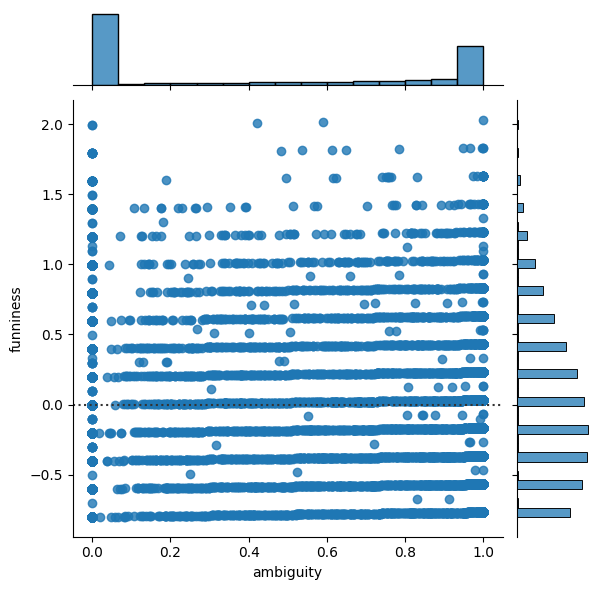

In [10]:
sns.jointplot(data=df_humicroedit_amb, y='funniness', x='ambiguity',
              palette='colorblind', kind='resid')
plt.savefig('../../results/img/humicroedit_kaoetal_ambiguity_funniness.pdf')

#### Visualize binned funniness

In [11]:
df_humicroedit_amb = df_humicroedit_amb.with_columns(pl.col('funniness')
    .qcut(3, labels=['low', 'mid', 'high'])
    .alias('funniness bin'))

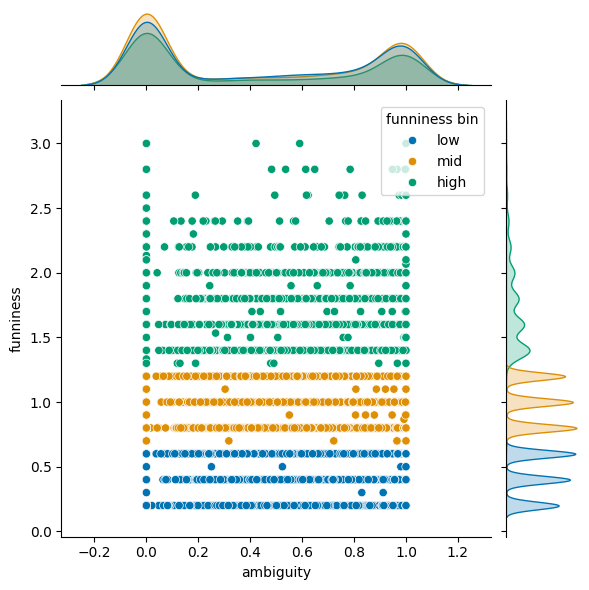

In [12]:
g = sns.jointplot(data=df_humicroedit_amb, y='funniness', x='ambiguity',
                  palette='colorblind', hue='funniness bin')
plt.savefig('../../results/img/humicroedit_kaoetal_ambiguity_binned_funniness.pdf')

### Distinctiveness

In [13]:
quantiles = (df.group_by('corpus')
               .agg(pl.col('distinctiveness').quantile(0.25).alias('Q1'),
                    pl.col('distinctiveness').quantile(0.5).alias('Q2'),
                    pl.col('distinctiveness').quantile(0.75).alias('Q3'))
               .with_columns((pl.col('Q3') - pl.col('Q1')).alias('IQR'))
               .with_columns((pl.col('Q1') - 1.5 * pl.col('IQR')).alias('F1'),
                             (pl.col('Q3') + 1.5 * pl.col('IQR')).alias('F2')))
quantiles

corpus,Q1,Q2,Q3,IQR,F1,F2
str,f64,f64,f64,f64,f64,f64
"""humicroedit""",0.0,0.0,0.0,0.0,0.0,0.0
"""puntuguese""",0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
df_with_quantiles = df.join(quantiles, on='corpus')
is_low_outlier = (pl.col('distinctiveness') < pl.col('F1'))
is_high_outlier = (pl.col('distinctiveness') > pl.col('F2'))
df_no_outliers_distinct = df_with_quantiles.filter(~(is_low_outlier | is_high_outlier)).select(df.columns)
df_no_outliers_distinct.group_by('corpus').len()

corpus,len
str,u64
"""puntuguese""",2298
"""humicroedit""",14296


#### Distinctiveness values without outliers

In [15]:
(df_no_outliers_distinct.group_by('corpus')
   .agg(pl.len().alias('count'),
        pl.col('distinctiveness').mean().alias('mean'),
        pl.col('distinctiveness').std().alias('std'),
        pl.col('distinctiveness').min().alias('min'),
        pl.col('distinctiveness').quantile(0.25).alias('25%'),
        pl.col('distinctiveness').quantile(0.5).alias('50%'),
        pl.col('distinctiveness').quantile(0.75).alias('75%'),
        pl.col('distinctiveness').max().alias('max'),
        pl.col('distinctiveness').skew().alias('skew'),
        pl.col('distinctiveness').kurtosis().alias('kurtosis')))

corpus,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
str,u64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""humicroedit""",14296,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
"""puntuguese""",2298,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


#### Humicroedit Ambiguity vs. Funniness

In [16]:
df_humicroedit_distinct = df_no_outliers_distinct.filter(pl.col('corpus') == 'humicroedit')

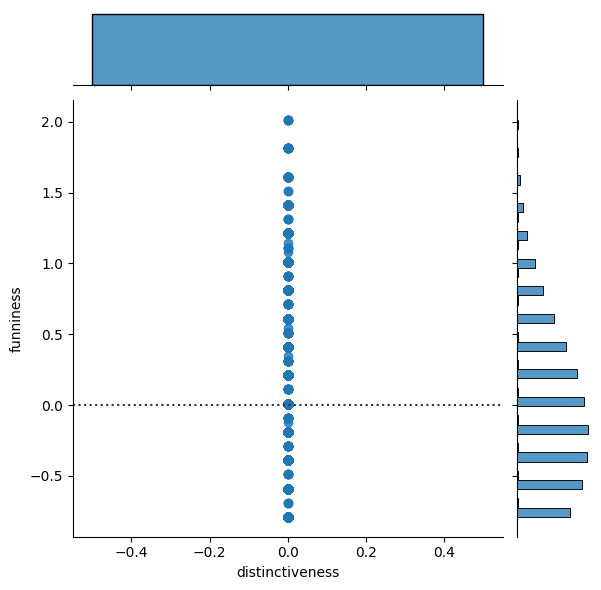

In [17]:
sns.jointplot(data=df_humicroedit_distinct, y='funniness', x='distinctiveness',
              palette='colorblind', kind='resid')
plt.savefig('../../results/img/humicroedit_kaoetal_distinctiveness_funniness.pdf')

#### Visualize binned funniness

In [19]:
df_humicroedit_distinct = df_humicroedit_distinct.with_columns(pl.col('funniness')
    .qcut(3, labels=['low', 'mid', 'high'])
    .alias('funniness bin'))

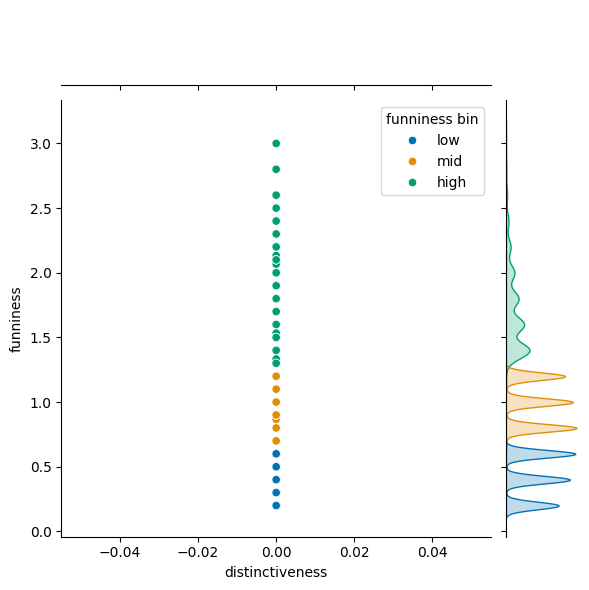

In [20]:
g = sns.jointplot(data=df_humicroedit_distinct, y='funniness', x='distinctiveness',
                  palette='colorblind', hue='funniness bin')
plt.savefig('../../results/img/humicroedit_kaoetal_distinctiveness_binned_funniness.pdf')

## Statistical tests (No outliers)

### Ambiguity

#### Consistency accross corpora — Mann-Whitney U

In [21]:
data_humicroedit = df_humicroedit_amb['ambiguity']
data_puntuguese = df_no_outliers_amb.filter(pl.col('corpus') == 'puntuguese')['ambiguity']
statistic, pvalue = mannwhitneyu(data_humicroedit, data_puntuguese)
print(f'Statistic = {statistic}')
print(f'P-value = {pvalue:.4f}')
print(f'Different distributions: {pvalue < 0.5}')

Statistic = 2572815.0
P-value = 0.0000
Different distributions: True


#### Humicroedit — Correlation Ambiguity vs. Funniness

In [22]:
(df_humicroedit_amb.select(['funniness', 'ambiguity']).corr()['ambiguity'][0])

-0.025894398151280546

#### Humicroedit — Binning analysis — Kruskal-Wallis H-test

In [23]:
binned_ambiguity = (df_humicroedit_amb.select(['ambiguity', 'funniness bin'])
                                      .group_by('funniness bin')
                                      .all()['ambiguity']
                                      .to_numpy())
statistic, pvalue = kruskal(*binned_ambiguity)
print(f'Statistic = {statistic}')
print(f'P-value = {pvalue:.4f}')
print(f'Different distributions: {pvalue < 0.5}')

Statistic = 8.804419359342527
P-value = 0.0123
Different distributions: True


In [24]:
dunn_result = posthoc_dunn(binned_ambiguity, p_adjust='bonferroni')
dunn_result.columns = ['low', 'mid', 'high']
dunn_result.index = ['low', 'mid', 'high']
dunn_result

,low,mid,high
low,1.000000,0.198594,0.010353
mid,0.198594,1.000000,0.650400
high,0.010353,0.650400,1.000000


### Distinctiveness

#### Consistency accross corpora — Mann-Whitney U

In [26]:
data_humicroedit = df_humicroedit_distinct['distinctiveness']
data_puntuguese = df_no_outliers_distinct.filter(pl.col('corpus') == 'puntuguese')['distinctiveness']
statistic, pvalue = mannwhitneyu(data_humicroedit, data_puntuguese)
print(f'Statistic = {statistic}')
print(f'P-value = {pvalue:.4f}')
print(f'Different distributions: {pvalue < 0.5}')

Statistic = 16426104.0
P-value = 1.0000
Different distributions: False
